In [423]:
import gzip
import os
from pathlib import Path
import re

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from dna_features_viewer import GraphicFeature, GraphicRecord
from Bio import SeqIO, SeqRecord, Phylo

cwd = os.getcwd()
if cwd.endswith('bacteriocins'):
    os.chdir('../..')
    cwd = os.getcwd()

from src.tree.tree_util import prune_leaves_with_unknown_id
from src.tree.itol_annotation import itol_labels

In [405]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('data')
assert data_folder.is_dir()

subtilosin_A_folder = data_folder / 'amp_db' / 'Subtilosin_A'
assert subtilosin_A_folder.is_dir()

subtilosin_A_out = Path('data/outputs/amp_db/Subtilosin_A')


In [406]:
gtdb_metadata = pd.read_csv(data_folder / 'amp_db' / 'gtdb_metadata.csv.gz', index_col='ncbi_accession')

In [178]:
def parse_gff(path : Path):
    gff_csv = pd.read_csv(
        path,
        sep='\t',
        comment='#',
        header=None,
        names=[
            'contig_id',
            'source',
            'type',
            'start',
            'end',
            'na1',
            'strand',
            'na2',
            'metadata',
        ],
    )

    def parse_protein_id(metadata : str):
        m = re.match(r'^.*protein_id=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None
        
    def parse_description(metadata : str):
        m = re.match(r'^.*product=([^;]+).*$', metadata)
        if m is not None:
            return m[1]
        else:
            return None

    gff_csv = gff_csv[gff_csv['type'] == 'CDS'].reset_index(drop=True)
    gff_csv['protein_id'] = gff_csv['metadata'].apply(parse_protein_id)
    gff_csv['description'] = gff_csv['metadata'].apply(parse_description)

    return gff_csv.drop_duplicates(['contig_id', 'protein_id']).reset_index(drop=True).set_index('protein_id')


In [179]:
B_subtilis_gff = parse_gff(subtilosin_A_folder / 'Bacillus subtilis' / 'GCF_000009045.1_ASM904v1_genomic.gff')
T_celer_gff = parse_gff(subtilosin_A_folder / 'Thermococcus celer' / 'GCF_002214365.1_ASM221436v1_genomic.gff')
T_nautili_gff = parse_gff(subtilosin_A_folder / 'Thermococcus nautili' / 'GCF_000585495.1_ASM58549v1_genomic.gff')

In [355]:
gtdb_metadata.loc[
    ['GCF_000009045.1', 'GCF_002214365.1', 'GCF_000585495.1']
][['gtdb_species', 'ncbi_organism_name', 'ncbi_assembly_level', 'checkm_completeness', 'checkm_contamination']]

,gtdb_species,ncbi_organism_name,ncbi_assembly_level,checkm_completeness,checkm_contamination
ncbi_accession,,,,,
GCF_000009045.1,Bacillus subtilis,Bacillus subtilis subsp. subtilis str. 168,Complete Genome,99.81,0.25
GCF_002214365.1,Thermococcus celer,Thermococcus celer Vu 13 = JCM 8558,Complete Genome,100.00,0.00
GCF_000585495.1,Thermococcus nautili,Thermococcus nautili,Complete Genome,100.00,0.00


In [181]:
def get_context(gff_df, core_protein_id, n_upstream=9_000, n_downstream=9_000):
    gff_row = gff_df.loc[core_protein_id]

    contig_id = gff_row['contig_id']
    start = max(gff_row['start'] - n_upstream, 1)
    end = gff_row['end'] + n_downstream

    return gff_df[
        (gff_df['contig_id'] == contig_id) &
        (gff_df['start'] >= start) &
        (gff_df['start'] < end) &
        (gff_df['end'] > start) &
        (gff_df['end'] <= end)
    ].copy()

In [182]:
B_subtilis_context = get_context(B_subtilis_gff, 'NP_391616.1', n_upstream=1000)
T_celer_context = get_context(T_celer_gff, 'WP_088863144.1')
T_nautili_context = get_context(T_nautili_gff, 'WP_042691590.1')

In [561]:
def plot_genes(aoi_df, color_map=None, label_map=None, ax=None, figure_width=20, no_labels=False, default_color='#cccccc'):
    features = []
    start = aoi_df['start'].min()
    end = aoi_df['end'].max()
    length = end - start + 1

    for _, row in aoi_df.iterrows():
        if no_labels:
            label = None
        elif label_map is not None:
            label = label_map[row.name]
        else:
            label = row['description']
    
        if color_map is not None and row.name in color_map:
            color = color_map[row.name]
        else:
            color = default_color

        features.append(
            GraphicFeature(
                start=row.start, 
                end=row.end, 
                strand=1 if row.strand == '+' else -1, 
                color=color,
                label=label,
            )
        )
    
    record = GraphicRecord(first_index=start, sequence_length=length, features=features)
    ax, _ = record.plot(figure_width=figure_width, ax=ax, with_ruler=True)
    ax.grid(False)
    return ax

In [184]:
B_subtilis_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
NP_391615.1,NC_000964.3,RefSeq,CDS,3835317,3835745,.,-,0,ID=cds-NP_391615.1;Parent=gene-BSU_37340;Dbxre...,putative RNA binding protein
NP_391616.1,NC_000964.3,RefSeq,CDS,3836058,3836189,.,+,0,ID=cds-NP_391616.1;Parent=gene-BSU_37350;Dbxre...,subtilosin A
YP_054594.1,NC_000964.3,RefSeq,CDS,3836146,3836298,.,+,0,ID=cds-YP_054594.1;Parent=gene-BSU_37360;Dbxre...,putative bacteriocin-like product
NP_391617.1,NC_000964.3,RefSeq,CDS,3836323,3837669,.,+,0,ID=cds-NP_391617.1;Parent=gene-BSU_37370;Dbxre...,subtilosin A thioether formation enzyme
NP_391618.1,NC_000964.3,RefSeq,CDS,3837682,3837843,.,+,0,ID=cds-NP_391618.1;Parent=gene-BSU_37380;Dbxre...,membrane component involved in subtilosin prod...
NP_391619.1,NC_000964.3,RefSeq,CDS,3837840,3838559,.,+,0,ID=cds-NP_391619.1;Parent=gene-BSU_37390;Dbxre...,putative transporter involved in subtilosin pr...
NP_391620.1,NC_000964.3,RefSeq,CDS,3838552,3839862,.,+,0,ID=cds-NP_391620.1;Parent=gene-BSU_37400;Dbxre...,integral membrane protein involved in subtilos...
NP_391621.1,NC_000964.3,RefSeq,CDS,3839852,3841012,.,+,0,ID=cds-NP_391621.1;Parent=gene-BSU_37410;Dbxre...,peptidase involved in subtilosin A production
NP_391622.1,NC_000964.3,RefSeq,CDS,3841017,3842297,.,+,0,ID=cds-NP_391622.1;Parent=gene-BSU_37420;Dbxre...,putative peptidase involved in subtilosin prod...


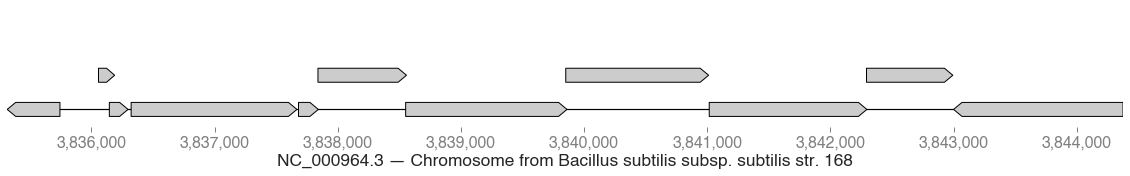

In [185]:
ax = plot_genes(B_subtilis_context, no_labels=True);

name = gtdb_metadata.loc['GCF_000009045.1', 'ncbi_organism_name']
contig_id = B_subtilis_context.iloc[0]['contig_id']
ax.set_xlabel(f'{contig_id} — Chromosome from {name}')

ax.get_figure().savefig('/Users/rs1521/Documents/00_Thesis/figures/raw/Subtilosin_A_from_B_subtilis_raw.pdf', dpi=300, bbox_inches='tight')

In [187]:
T_celer_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_088863138.1,NZ_CP014854.1,Protein Homology,CDS,1142436,1142879,.,+,0,ID=cds-WP_088863138.1;Parent=gene-A3L02_RS0635...,Tfx family DNA-binding protein
WP_088863139.1,NZ_CP014854.1,Protein Homology,CDS,1143000,1144457,.,+,0,ID=cds-WP_088863139.1;Parent=gene-A3L02_RS0636...,DUF2139 domain-containing protein
WP_088863140.1,NZ_CP014854.1,Protein Homology,CDS,1144495,1144800,.,-,0,ID=cds-WP_088863140.1;Parent=gene-A3L02_RS0636...,DUF3213 domain-containing protein
WP_237268581.1,NZ_CP014854.1,Protein Homology,CDS,1144811,1147942,.,-,0,ID=cds-WP_237268581.1;Parent=gene-A3L02_RS0637...,radical SAM protein
WP_088863141.1,NZ_CP014854.1,Protein Homology,CDS,1148127,1148483,.,+,0,ID=cds-WP_088863141.1;Parent=gene-A3L02_RS0637...,hypothetical protein
WP_088863142.1,NZ_CP014854.1,Protein Homology,CDS,1148493,1149077,.,+,0,ID=cds-WP_088863142.1;Parent=gene-A3L02_RS0638...,type-4 uracil-DNA glycosylase
WP_088863143.1,NZ_CP014854.1,Protein Homology,CDS,1149389,1150984,.,+,0,ID=cds-WP_088863143.1;Parent=gene-A3L02_RS0638...,Na+/H+ antiporter NhaC family protein
WP_088863144.1,NZ_CP014854.1,Protein Homology,CDS,1151165,1151302,.,+,0,ID=cds-WP_088863144.1;Parent=gene-A3L02_RS0639...,subtilosin A family bacteriocin
WP_088863145.1,NZ_CP014854.1,Protein Homology,CDS,1151401,1152729,.,+,0,ID=cds-WP_088863145.1;Parent=gene-A3L02_RS0639...,radical SAM protein


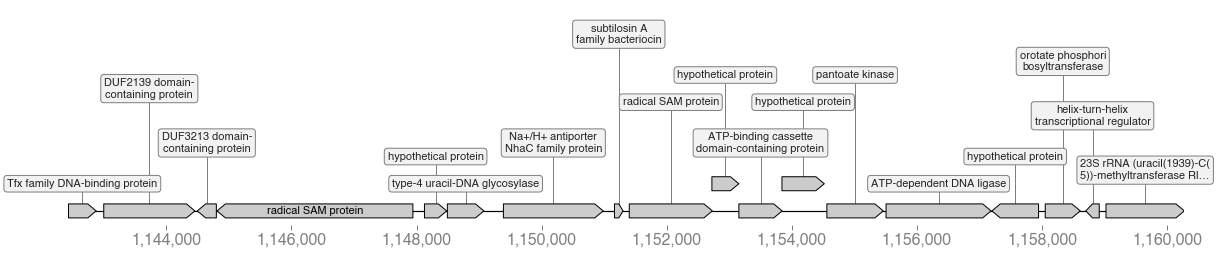

In [188]:
#plot_genes(T_celer_context[T_celer_context['source'] == 'Protein Homology']);
plot_genes(T_celer_context);

In [189]:
T_nautili_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_042691567.1,NZ_CP007264.1,Protein Homology,CDS,1376989,1377204,.,+,0,ID=cds-WP_042691567.1;Parent=gene-BD01_RS07540...,hypothetical protein
WP_042691569.1,NZ_CP007264.1,Protein Homology,CDS,1377251,1378078,.,+,0,ID=cds-WP_042691569.1;Parent=gene-BD01_RS07545...,MinD/ParA family protein
WP_042691571.1,NZ_CP007264.1,Protein Homology,CDS,1378040,1378588,.,-,0,ID=cds-WP_042691571.1;Parent=gene-BD01_RS07550...,orotate phosphoribosyltransferase
WP_042691574.1,NZ_CP007264.1,Protein Homology,CDS,1378712,1379512,.,+,0,ID=cds-WP_042691574.1;Parent=gene-BD01_RS07555...,PrsW family glutamic-type intramembrane protease
WP_042693257.1,NZ_CP007264.1,Protein Homology,CDS,1379496,1381175,.,-,0,ID=cds-WP_042693257.1;Parent=gene-BD01_RS07560...,ATP-dependent DNA ligase
WP_042691577.1,NZ_CP007264.1,Protein Homology,CDS,1381325,1381630,.,+,0,ID=cds-WP_042691577.1;Parent=gene-BD01_RS07565...,nucleotidyltransferase domain-containing protein
WP_042691580.1,NZ_CP007264.1,Protein Homology,CDS,1381627,1382529,.,-,0,ID=cds-WP_042691580.1;Parent=gene-BD01_RS07570...,pantoate kinase
WP_042691582.1,NZ_CP007264.1,GeneMarkS-2+,CDS,1382569,1383225,.,-,0,ID=cds-WP_042691582.1;Parent=gene-BD01_RS07575...,hypothetical protein
WP_051482183.1,NZ_CP007264.1,Protein Homology,CDS,1383222,1383914,.,-,0,ID=cds-WP_051482183.1;Parent=gene-BD01_RS07580...,ABC transporter ATP-binding protein


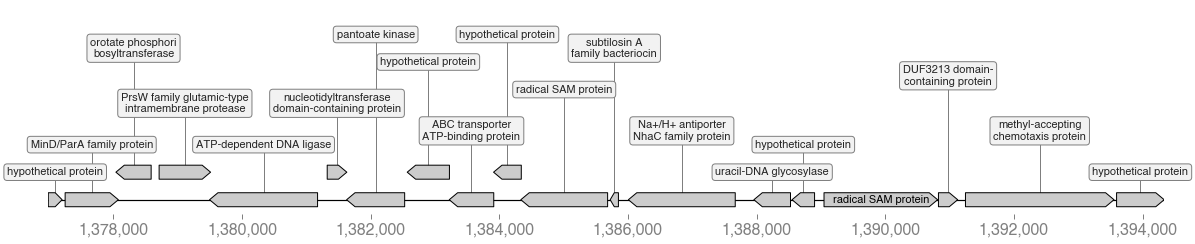

In [190]:
#plot_genes(T_nautili_context[T_nautili_context['source'] == 'Protein Homology']);
plot_genes(T_nautili_context);

### Put sequences together

to perform all vs all search with phmmer

In [191]:
query_proteins = {p for p in B_subtilis_context.index}
target_proteins = set(T_celer_context.index) | set(T_nautili_context.index)

query_records = []
for record in SeqIO.parse(subtilosin_A_folder / 'Bacillus subtilis' / 'GCF_000009045.1_ASM904v1_protein.faa', 'fasta'):
    if record.id in query_proteins:
        query_records.append(record)


target_records = []
for path in (
    subtilosin_A_folder / 'Thermococcus celer' / 'GCF_002214365.1_ASM221436v1_protein.faa', 
    subtilosin_A_folder / 'Thermococcus nautili' / 'GCF_000585495.1_ASM58549v1_protein.faa',
):
    for record in SeqIO.parse(path, 'fasta'):
        if record.id in target_proteins:
            target_records.append(record)

with (subtilosin_A_out / 'query_proteins.fasta') as f_query_out:
    SeqIO.write(query_records, f_query_out, 'fasta')

with (subtilosin_A_out / 'target_proteins.fasta') as f_target_out:
    SeqIO.write(target_records, f_target_out, 'fasta')

### Export sboA, albA, albC and their homologs in Thermococcus

9 proteins in total. These proteins will be searched against the entire DB for the purpose of building a phylogenetic tree.

In [192]:
key_proteins = {
    # sboA and homologs
    'NP_391616.1',
    'WP_088863144.1',
    'WP_042691590.1',

    # albA and homologs
    'NP_391617.1',
    'WP_088863145.1',
    'WP_042691587.1',

    # albC and homologs
    'NP_391619.1',
    'WP_157895742.1',
    'WP_051482183.1',
}

key_records = []
for path in (
    subtilosin_A_folder / 'Bacillus subtilis' / 'GCF_000009045.1_ASM904v1_protein.faa',
    subtilosin_A_folder / 'Thermococcus celer' / 'GCF_002214365.1_ASM221436v1_protein.faa', 
    subtilosin_A_folder / 'Thermococcus nautili' / 'GCF_000585495.1_ASM58549v1_protein.faa',
):
    for record in SeqIO.parse(path, 'fasta'):
        if record.id in key_proteins:
            key_records.append(record)

with (subtilosin_A_out / 'sboA_albA_albC.fasta') as f_out:
    SeqIO.write(key_records, f_out, 'fasta')

### sboA, albA and albC homologs

In [193]:
sbo_alb_homologs = pd.read_csv(subtilosin_A_folder / 'sboA_albA_albC_homologs.tsv', sep='\t')
sbo_alb_homologs['assembly_accession'] = sbo_alb_homologs['target'].apply(lambda t: t.split('@')[1])
sbo_alb_homologs['protein_id'] = sbo_alb_homologs['target'].apply(lambda t: t.split('@')[0])
sbo_alb_homologs = pd.merge(
    sbo_alb_homologs,
    gtdb_metadata.reset_index().rename(
        columns={'ncbi_accession': 'assembly_accession'}
    )[['assembly_accession', 'gtdb_species', 'ncbi_organism_name', 'ncbi_assembly_level', 'checkm_completeness', 'ncbi_assembly_name']],
    on='assembly_accession',
    how='left',
)
sbo_alb_homologs.head()

,query,target,evalue,bits,tstart,tend,assembly_accession,protein_id,gtdb_species,ncbi_organism_name,ncbi_assembly_level,checkm_completeness,ncbi_assembly_name
0,WP_157895742.1,WP_157895742.1@GCF_002214365.1,2.078000e-144,460,1,230,GCF_002214365.1,WP_157895742.1,Thermococcus celer,Thermococcus celer Vu 13 = JCM 8558,Complete Genome,100.00,ASM221436v1
1,WP_157895742.1,WP_051482183.1@GCF_000585495.1,5.015000e-94,315,1,227,GCF_000585495.1,WP_051482183.1,Thermococcus nautili,Thermococcus nautili,Complete Genome,100.00,ASM58549v1
2,WP_157895742.1,WP_049684515.1@GCF_000763575.1,6.638000e-68,239,1,213,GCF_000763575.1,WP_049684515.1,Thermoanaerobacter kivui,Thermoanaerobacter kivui,Complete Genome,98.93,ASM76357v1
3,WP_157895742.1,WP_072966919.1@GCF_900129115.1,6.006000e-67,237,1,213,GCF_900129115.1,WP_072966919.1,Thermoanaerobacter uzonensis,Thermoanaerobacter uzonensis DSM 18761,Scaffold,99.52,IMG-taxon 2582581276 annotated assembly
4,WP_157895742.1,CP033580.1_877@GCA_003722315.1,6.006000e-67,237,1,206,GCA_003722315.1,CP033580.1_877,Thermoanaerobacter ethanolicus,Thermoanaerobacter ethanolicus JW 200,Complete Genome,99.52,ASM372231v1


Keep only genomes that match at least one of each key gene.

In [194]:
sboA_homologs = {
    'NP_391616.1',
    'WP_088863144.1',
    'WP_042691590.1',
}
albA_homologs = {
    'NP_391617.1',
    'WP_088863145.1',
    'WP_042691587.1',
}
albC_homologs = {
    'NP_391619.1',
    'WP_157895742.1',
    'WP_051482183.1',
}

candidate_accessions = []
for assembly_accession in sbo_alb_homologs['assembly_accession'].unique():
    queries = set(sbo_alb_homologs[
        sbo_alb_homologs['assembly_accession'] == assembly_accession
    ]['query'].unique())

    if len(queries & sboA_homologs) > 0 and len(queries & albA_homologs) and len(queries & albC_homologs):
        candidate_accessions.append(assembly_accession)

assert 'GCF_000009045.1' in candidate_accessions
assert 'GCF_002214365.1' in candidate_accessions
assert 'GCF_000585495.1' in candidate_accessions

print(len(candidate_accessions))

12


In [211]:
candidates = gtdb_metadata.loc[candidate_accessions]

candidates[
    ['domain', 'gtdb_phylum', 'gtdb_class', 'gtdb_order', 'gtdb_family', 'gtdb_species', 'ncbi_organism_name', 'ncbi_assembly_level', 'checkm_completeness']
].sort_values(['domain', 'gtdb_phylum', 'gtdb_class', 'gtdb_species', 'ncbi_organism_name'])

,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_species,ncbi_organism_name,ncbi_assembly_level,checkm_completeness
ncbi_accession,,,,,,,,,
GCF_002214365.1,Archaea,Methanobacteriota_B,Thermococci,Thermococcales,Thermococcaceae,Thermococcus celer,Thermococcus celer Vu 13 = JCM 8558,Complete Genome,100.00
GCF_000585495.1,Archaea,Methanobacteriota_B,Thermococci,Thermococcales,Thermococcaceae,Thermococcus nautili,Thermococcus nautili,Complete Genome,100.00
GCF_900099925.1,Bacteria,Bacillota,Bacilli,Aneurinibacillales,Aneurinibacillaceae,Aneurinibacillus thermoaerophilus,Aneurinibacillus thermoaerophilus,Scaffold,96.89
GCF_001584335.1,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Bacillus atrophaeus,Bacillus atrophaeus,Scaffold,99.17
GCF_001517105.1,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Bacillus halotolerans,Bacillus halotolerans,Contig,98.69
GCF_000227465.1,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Bacillus spizizenii,Bacillus subtilis subsp. spizizenii TU-B-10,Complete Genome,99.74
GCF_000009045.1,Bacteria,Bacillota,Bacilli,Bacillales,Bacillaceae,Bacillus subtilis,Bacillus subtilis subsp. subtilis str. 168,Complete Genome,99.81
GCF_001050115.1,Bacteria,Bacillota,Bacilli,Bacillales,JACDOC01,Bacillus_O smithii,Bacillus smithii,Complete Genome,99.04
GCF_001885905.1,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus_A devriesei,Enterococcus devriesei,Scaffold,99.31


In [196]:
candidate_homologs = sbo_alb_homologs[
    sbo_alb_homologs['assembly_accession'].isin(candidate_accessions)
    & (sbo_alb_homologs['assembly_accession'].str.startswith('GCF_'))
].copy()

def query_name_fn(q):
    if q in sboA_homologs:
        return 'sboA'
    elif q in albA_homologs:
        return 'albA'
    elif q in albC_homologs:
        return 'albC'
    else:
        raise ValueError(f'Unknown query: {q}')

candidate_homologs['query_name'] = candidate_homologs['query'].apply(query_name_fn)

candidate_homologs = candidate_homologs.sort_values(
    ['assembly_accession', 'query_name', 'bits'],
    ascending=[True, True, False],
).drop_duplicates(['assembly_accession', 'query_name'])

In [197]:
candidate_homologs

,query,target,evalue,bits,tstart,tend,assembly_accession,protein_id,gtdb_species,ncbi_organism_name,ncbi_assembly_level,checkm_completeness,ncbi_assembly_name,query_name
1462,NP_391617.1,NP_391617.1@GCF_000009045.1,1.218000e-310,952,1,448,GCF_000009045.1,NP_391617.1,Bacillus subtilis,Bacillus subtilis subsp. subtilis str. 168,Complete Genome,99.81,ASM904v1,albA
1938,NP_391619.1,NP_391619.1@GCF_000009045.1,1.930000e-152,484,1,239,GCF_000009045.1,NP_391619.1,Bacillus subtilis,Bacillus subtilis subsp. subtilis str. 168,Complete Genome,99.81,ASM904v1,albC
1446,NP_391616.1,NP_391616.1@GCF_000009045.1,3.595000e-21,94,1,43,GCF_000009045.1,NP_391616.1,Bacillus subtilis,Bacillus subtilis subsp. subtilis str. 168,Complete Genome,99.81,ASM904v1,sboA
1463,NP_391617.1,WP_014115546.1@GCF_000227465.1,1.026000e-305,938,1,448,GCF_000227465.1,WP_014115546.1,Bacillus spizizenii,Bacillus subtilis subsp. spizizenii TU-B-10,Complete Genome,99.74,ASM22746v1,albA
1939,NP_391619.1,WP_014115548.1@GCF_000227465.1,2.476000e-148,472,1,239,GCF_000227465.1,WP_014115548.1,Bacillus spizizenii,Bacillus subtilis subsp. spizizenii TU-B-10,Complete Genome,99.74,ASM22746v1,albC
1447,NP_391616.1,WP_003222002.1@GCF_000227465.1,3.595000e-21,94,1,43,GCF_000227465.1,WP_003222002.1,Bacillus spizizenii,Bacillus subtilis subsp. spizizenii TU-B-10,Complete Genome,99.74,ASM22746v1,sboA
492,WP_042691587.1,WP_042691587.1@GCF_000585495.1,1.663000e-303,932,1,449,GCF_000585495.1,WP_042691587.1,Thermococcus nautili,Thermococcus nautili,Complete Genome,100.00,ASM58549v1,albA
968,WP_051482183.1,WP_051482183.1@GCF_000585495.1,8.311000e-142,452,1,230,GCF_000585495.1,WP_051482183.1,Thermococcus nautili,Thermococcus nautili,Complete Genome,100.00,ASM58549v1,albC
476,WP_042691590.1,WP_042691590.1@GCF_000585495.1,1.958000e-22,98,1,42,GCF_000585495.1,WP_042691590.1,Thermococcus nautili,Thermococcus nautili,Complete Genome,100.00,ASM58549v1,sboA
1467,NP_391617.1,WP_039236238.1@GCF_000812025.2,2.075000e-160,518,4,444,GCF_000812025.2,WP_039236238.1,Quasibacillus thermotolerans,Quasibacillus thermotolerans,Contig,99.34,ASM81202v2,albA


### Make sure hits are within a 18 kb window

In [198]:
df = candidate_homologs[
    candidate_homologs['query_name'] == 'sboA'
][['assembly_accession', 'protein_id', 'gtdb_species']]

final_accessions = []
contexts = {}
for assembly_accession, protein_id, gtdb_species in df.values:
    folder = subtilosin_A_folder / f'{gtdb_species}'
    assert folder.is_dir()

    gff_file = None
    for f in folder.iterdir():
        if f.name.endswith('.gff.gz'):
            gff_file = f
            break

    assert gff_file is not None

    gff = parse_gff(gff_file)

    context = get_context(gff, protein_id, n_upstream=9_000, n_downstream=9_000)

    protein_ids = set(candidate_homologs[candidate_homologs['assembly_accession'] == assembly_accession]['protein_id'].unique())
    if len(set(context.index) & set(protein_ids)) == 3:
        decision = 'yes'
        final_accessions.append(assembly_accession)
        contexts[assembly_accession] = context
    else:
        decision = 'no'

    print(f'{assembly_accession} - {gtdb_species}: {decision}')


GCF_000009045.1 - Bacillus subtilis: yes
GCF_000227465.1 - Bacillus spizizenii: yes
GCF_000585495.1 - Thermococcus nautili: yes
GCF_000812025.2 - Quasibacillus thermotolerans: yes
GCF_000955725.1 - Caldicellulosiruptor danielii: yes
GCF_001050115.1 - Bacillus_O smithii: yes
GCF_001517105.1 - Bacillus halotolerans: yes
GCF_001584335.1 - Bacillus atrophaeus: yes
GCF_001885905.1 - Enterococcus_A devriesei: yes
GCF_002214365.1 - Thermococcus celer: yes
GCF_900099925.1 - Aneurinibacillus thermoaerophilus: yes


In [199]:
final_homologs = candidate_homologs[candidate_homologs['assembly_accession'].isin(final_accessions)].reset_index(drop=True)

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_235375198.1,NZ_LACM01000001.1,Protein Homology,CDS,1205717,1206520,.,+,0,ID=cds-WP_235375198.1;Parent=gene-N913_RS05330...,hypothetical protein
WP_045174431.1,NZ_LACM01000001.1,Protein Homology,CDS,1206544,1206975,.,+,0,ID=cds-WP_045174431.1;Parent=gene-N913_RS05335...,hypothetical protein
WP_045174435.1,NZ_LACM01000001.1,GeneMarkS-2+,CDS,1208304,1208708,.,+,0,ID=cds-WP_045174435.1;Parent=gene-N913_RS05350...,hypothetical protein
WP_045174436.1,NZ_LACM01000001.1,Protein Homology,CDS,1209071,1210153,.,+,0,ID=cds-WP_045174436.1;Parent=gene-N913_RS05360...,hypothetical protein
WP_045174438.1,NZ_LACM01000001.1,Protein Homology,CDS,1210258,1211007,.,+,0,ID=cds-WP_045174438.1;Parent=gene-N913_RS05365...,hypothetical protein
WP_235375199.1,NZ_LACM01000001.1,GeneMarkS-2+,CDS,1211625,1212626,.,+,0,ID=cds-WP_235375199.1;Parent=gene-N913_RS05370...,hypothetical protein
WP_045174439.1,NZ_LACM01000001.1,Protein Homology,CDS,1212693,1213892,.,+,0,ID=cds-WP_045174439.1;Parent=gene-N913_RS05375...,hypothetical protein
WP_200891860.1,NZ_LACM01000001.1,Protein Homology,CDS,1214708,1214842,.,+,0,ID=cds-WP_200891860.1;Parent=gene-N913_RS13690...,subtilosin A family bacteriocin
WP_200891844.1,NZ_LACM01000001.1,Protein Homology,CDS,1214954,1216018,.,+,0,ID=cds-WP_200891844.1;Parent=gene-N913_RS13575...,radical SAM protein


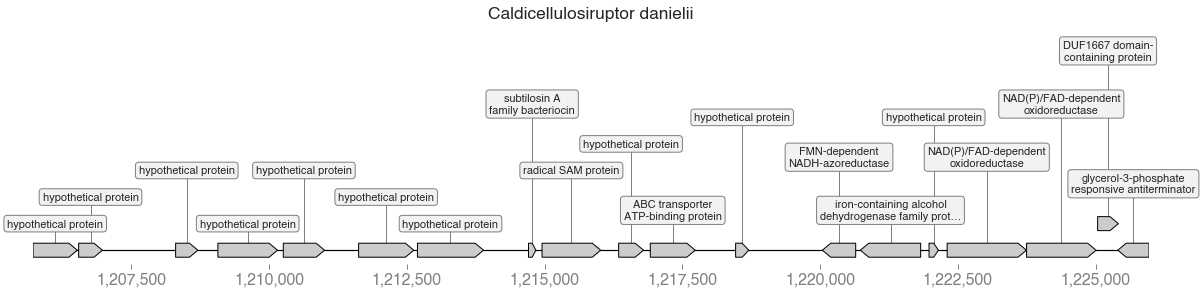

In [356]:
accession = 'GCF_000955725.1'
gtdb_species = gtdb_metadata.loc[accession, 'gtdb_species']
protein_id = candidate_homologs[
    (candidate_homologs['query_name'] == 'sboA') &
    (candidate_homologs['assembly_accession'] == accession)
].iloc[0]['protein_id']

folder = subtilosin_A_folder / f'{gtdb_species}'
assert folder.is_dir()

gff_file = None
for f in folder.iterdir():
    if f.name.endswith('.gff.gz'):
        gff_file = f
        break

assert gff_file is not None

gff = parse_gff(gff_file)

context = get_context(gff, protein_id, n_upstream=9_000, n_downstream=12_000)

ax = plot_genes(context);
ax.set_title(gtdb_species)

contexts[accession]

### Export proteins

For the purpose of aligning them.

In [ ]:
sboA_proteins = []
albA_proteins = []
albC_proteins = []

for _, row in final_homologs.iterrows():
    assembly_accession = row['assembly_accession']
    protein_id = row['protein_id']
    query_name = row['query_name']
    gtdb_species = row['gtdb_species']

    folder = subtilosin_A_folder / f'{gtdb_species}'
    assert folder.is_dir()

    fasta_file = None
    for f in folder.iterdir():
        if f.name.endswith('_protein.faa.gz'):
            fasta_file = f
            break

    assert fasta_file is not None

    with gzip.open(fasta_file, mode='rt') as f:
        for record in SeqIO.parse(f, 'fasta'):
            if record.id == protein_id:
                record.id = f"{record.id}@{assembly_accession}${gtdb_species.replace(' ', '_')}"

                if query_name == 'sboA':
                    sboA_proteins.append(record)
                elif query_name == 'albA':
                    albA_proteins.append(record)
                elif query_name == 'albC':
                    albC_proteins.append(record)
                else:
                    raise ValueError(f'Unknown query {query_name}')

with (subtilosin_A_out / 'sboA_proteins.fasta') as f_out:
    SeqIO.write(sboA_proteins, f_out, 'fasta')

with (subtilosin_A_out / 'albA_proteins.fasta') as f_out:
    SeqIO.write(albA_proteins, f_out, 'fasta')

with (subtilosin_A_out / 'albC_proteins.fasta') as f_out:
    SeqIO.write(albC_proteins, f_out, 'fasta')

### Concatenate alignments

In [209]:
sboA_records = SeqIO.parse(subtilosin_A_folder / 'sboA_proteins.aln.clip.fasta', 'fasta')
albA_records = SeqIO.parse(subtilosin_A_folder / 'albA_proteins.aln.clip.fasta', 'fasta')
albC_records = SeqIO.parse(subtilosin_A_folder / 'albC_proteins.aln.clip.fasta', 'fasta')

concatenated_records = []
for record1, record2, record3 in zip(sboA_records, albA_records, albC_records):

    accession1 = record1.id.split('@')[1].split('$')[0]
    accession2 = record2.id.split('@')[1].split('$')[0]
    accession3 = record3.id.split('@')[1].split('$')[0]

    assert accession1 == accession2 and accession2 == accession3

    concatenated_sequence = record1.seq + record2.seq + record3.seq

    new_id = f"sboA_albA_albC@{record1.id.split('@')[1]}"

    new_record = SeqRecord.SeqRecord(
        concatenated_sequence,
        id=new_id,
        description='',
        name='',
    )
    concatenated_records.append(new_record)

with (subtilosin_A_out / 'sboA_albA_albC.aln.fasta') as f_out:
    SeqIO.write(concatenated_records, f_out, 'fasta')

### Export all context proteins

In [214]:
all_proteins = []
for assembly_accession in final_homologs['assembly_accession'].unique():
    gtdb_species = gtdb_metadata.loc[assembly_accession, 'gtdb_species']

    folder = subtilosin_A_folder / f'{gtdb_species}'
    assert folder.is_dir()

    fasta_file = None
    for f in folder.iterdir():
        if f.name.endswith('_protein.faa.gz'):
            fasta_file = f
            break

    assert fasta_file is not None

    context = contexts[assembly_accession]
    context_proteins = set(context.index)

    with gzip.open(fasta_file, mode='rt') as f:
        for record in SeqIO.parse(f, 'fasta'):
            if record.id in context_proteins:
                record.id = f"{record.id}@{assembly_accession}${gtdb_species.replace(' ', '_')}"
                all_proteins.append(record)

with (subtilosin_A_out / 'sbo_alb_proteins.fasta') as f_out:
    SeqIO.write(all_proteins, f_out, 'fasta')

### Contexts

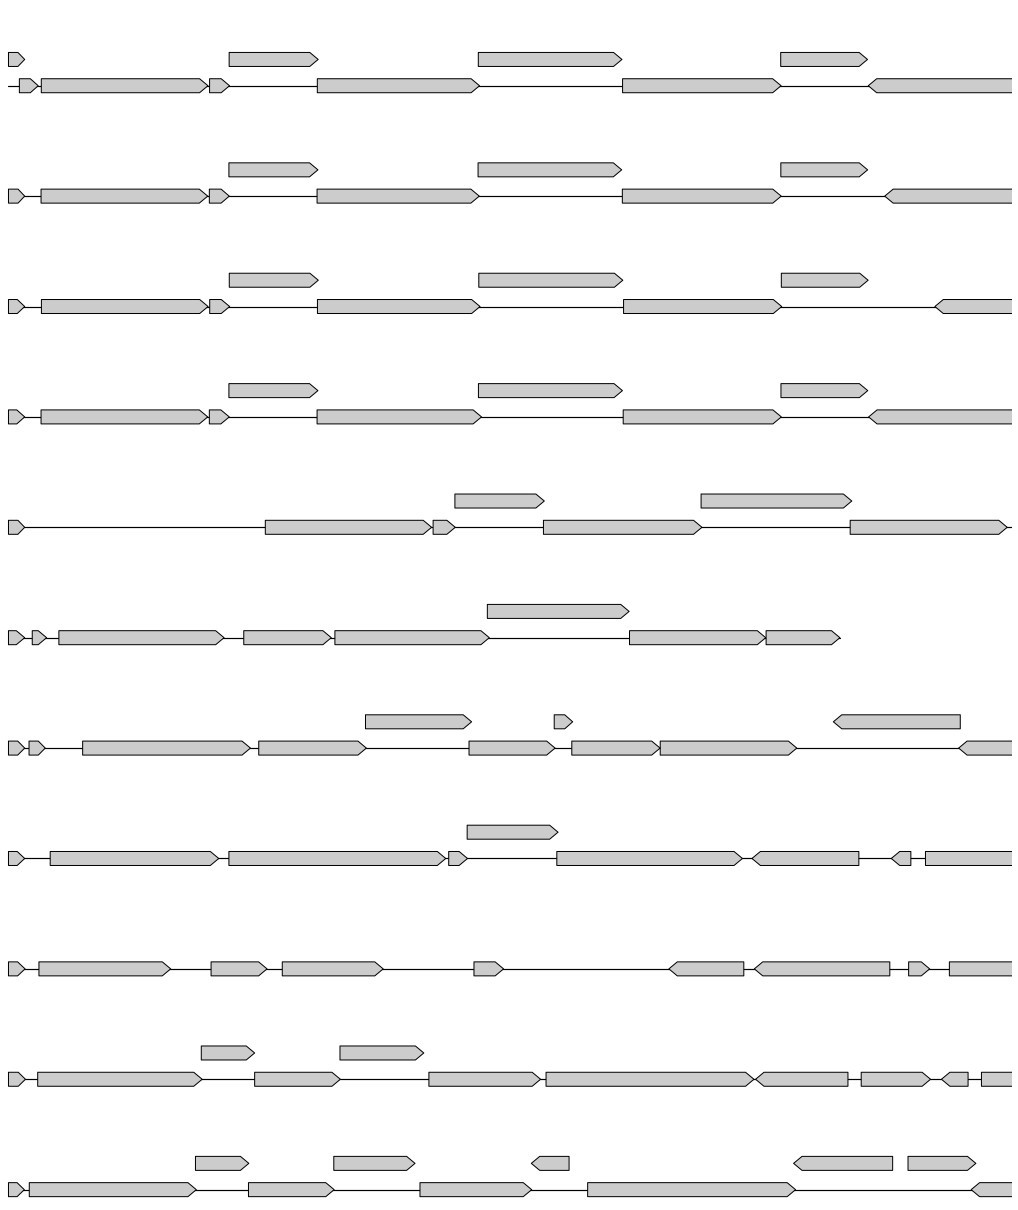

In [290]:
accessions = [
    'GCF_000009045.1',
    'GCF_000227465.1',
    'GCF_001517105.1',
    'GCF_001584335.1',
    'GCF_001050115.1',
    'GCF_000812025.2',
    'GCF_001885905.1',
    'GCF_900099925.1',
    'GCF_000955725.1',
    'GCF_002214365.1',
    'GCF_000585495.1',
]
n_rows = len(accessions)
fig, axes = plt.subplots(n_rows, 1, figsize=(18, 2 * len(accessions)))

upstream = 500
downstream = 10_000
max_display_length = 8_100
lengths = []
for i, accession in enumerate(accessions):
    ax = axes[i]
    gtdb_species = gtdb_metadata.loc[accession, 'gtdb_species']

    folder = subtilosin_A_folder / f'{gtdb_species}'
    assert folder.is_dir()

    gff_file = None
    for f in folder.iterdir():
        if f.name.endswith('.gff.gz'):
            gff_file = f
            break

    assert gff_file is not None

    gff = parse_gff(gff_file)

    core_protein_id = final_homologs[
        (final_homologs['assembly_accession'] == accession) &
        (final_homologs['query_name'] == 'sboA')
    ].iloc[0]['protein_id']

    strand = gff.loc[core_protein_id, 'strand']

    gene_context = get_context(
        gff, 
        core_protein_id, 
        n_upstream=upstream if strand == '+' else downstream,
        n_downstream=downstream if strand == '+' else upstream,
    )

    if strand == '-':
        # swap
        df = gene_context.reset_index()
        contig_length = df['end'].max()
        old_start = df['start'].copy()
        old_end = df['end'].copy()

        df['start'] = contig_length - old_end + 1
        df['end'] = contig_length - old_start + 1

        df['strand'] = df['strand'].map({'+': '-', '-': '+'})

        # 4. Re-order Proteins by their new start position
        gene_context = df.sort_values(by='start').reset_index(drop=True).set_index('protein_id')

    ax = plot_genes(gene_context, ax=ax, no_labels=True);

    left, _ = ax.get_xlim()
    right = start = gene_context.iloc[0]['start'] + max_display_length
    ax.set_xlim(left - 10, right)
    ax.get_xaxis().set_visible(False)
    
fig.savefig(f'/Users/rs1521/Documents/00_Thesis/figures/raw/gene_context_raw.pdf', dpi=300, bbox_inches='tight')

### All vs all homology

In [308]:
def parse_tblout(path):
    return pd.read_csv(
        path, 
        sep='\s+', 
        comment='#', 
        header=None,
        usecols=[0, 2, 4, 5],
        names=[
            'target', 'query', 'evalue', 'bitscore',
        ],
    )

In [317]:
all_vs_all = parse_tblout(subtilosin_A_folder / 'sboA_albA_albC_all_vs_all.tblout.txt')

all_vs_all['query_accession'] = all_vs_all['query'].apply(lambda v: v.split('@')[1].split('$')[0])
all_vs_all['query_protein_id'] = all_vs_all['query'].apply(lambda v: v.split('@')[0])
all_vs_all['query_species'] = all_vs_all['query'].apply(lambda v: v.split('@')[1].split('$')[1])

all_vs_all['target_accession'] = all_vs_all['target'].apply(lambda v: v.split('@')[1].split('$')[0])
all_vs_all['target_protein_id'] = all_vs_all['target'].apply(lambda v: v.split('@')[0])
all_vs_all['target_species'] = all_vs_all['target'].apply(lambda v: v.split('@')[1].split('$')[1])

all_vs_all.head()

,target,query,evalue,bitscore,query_accession,query_protein_id,query_species,target_accession,target_protein_id,target_species
0,NP_391610.1@GCF_000009045.1$Bacillus_subtilis,NP_391610.1@GCF_000009045.1$Bacillus_subtilis,6.000000e-109,354.2,GCF_000009045.1,NP_391610.1,Bacillus_subtilis,GCF_000009045.1,NP_391610.1,Bacillus_subtilis
1,WP_014115540.1@GCF_000227465.1$Bacillus_spiziz...,NP_391610.1@GCF_000009045.1$Bacillus_subtilis,1.700000e-102,333.2,GCF_000009045.1,NP_391610.1,Bacillus_subtilis,GCF_000227465.1,WP_014115540.1,Bacillus_spizizenii
2,WP_059335151.1@GCF_001517105.1$Bacillus_haloto...,NP_391610.1@GCF_000009045.1$Bacillus_subtilis,1.200000e-91,298.0,GCF_000009045.1,NP_391610.1,Bacillus_subtilis,GCF_001517105.1,WP_059335151.1,Bacillus_halotolerans
3,WP_003326508.1@GCF_001584335.1$Bacillus_atroph...,NP_391610.1@GCF_000009045.1$Bacillus_subtilis,9.800000e-82,265.8,GCF_000009045.1,NP_391610.1,Bacillus_subtilis,GCF_001584335.1,WP_003326508.1,Bacillus_atrophaeus
4,NP_391611.1@GCF_000009045.1$Bacillus_subtilis,NP_391611.1@GCF_000009045.1$Bacillus_subtilis,2.400000e-167,548.4,GCF_000009045.1,NP_391611.1,Bacillus_subtilis,GCF_000009045.1,NP_391611.1,Bacillus_subtilis


,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_088863138.1,NZ_CP014854.1,Protein Homology,CDS,1142436,1142879,.,+,0,ID=cds-WP_088863138.1;Parent=gene-A3L02_RS0635...,Tfx family DNA-binding protein
WP_088863139.1,NZ_CP014854.1,Protein Homology,CDS,1143000,1144457,.,+,0,ID=cds-WP_088863139.1;Parent=gene-A3L02_RS0636...,DUF2139 domain-containing protein
WP_088863140.1,NZ_CP014854.1,Protein Homology,CDS,1144495,1144800,.,-,0,ID=cds-WP_088863140.1;Parent=gene-A3L02_RS0636...,DUF3213 domain-containing protein
WP_237268581.1,NZ_CP014854.1,Protein Homology,CDS,1144811,1147942,.,-,0,ID=cds-WP_237268581.1;Parent=gene-A3L02_RS0637...,radical SAM protein
WP_088863141.1,NZ_CP014854.1,Protein Homology,CDS,1148127,1148483,.,+,0,ID=cds-WP_088863141.1;Parent=gene-A3L02_RS0637...,hypothetical protein
WP_088863142.1,NZ_CP014854.1,Protein Homology,CDS,1148493,1149077,.,+,0,ID=cds-WP_088863142.1;Parent=gene-A3L02_RS0638...,type-4 uracil-DNA glycosylase
WP_088863143.1,NZ_CP014854.1,Protein Homology,CDS,1149389,1150984,.,+,0,ID=cds-WP_088863143.1;Parent=gene-A3L02_RS0638...,Na+/H+ antiporter NhaC family protein
WP_088863144.1,NZ_CP014854.1,Protein Homology,CDS,1151165,1151302,.,+,0,ID=cds-WP_088863144.1;Parent=gene-A3L02_RS0639...,subtilosin A family bacteriocin
WP_088863145.1,NZ_CP014854.1,Protein Homology,CDS,1151401,1152729,.,+,0,ID=cds-WP_088863145.1;Parent=gene-A3L02_RS0639...,radical SAM protein


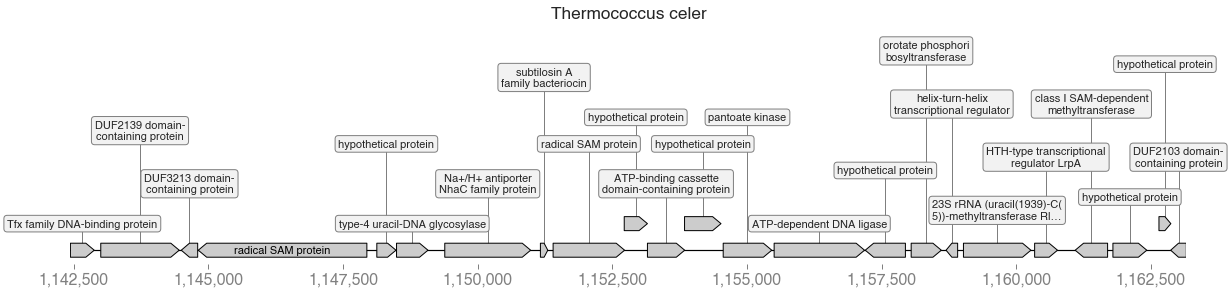

In [ ]:
accession = 'GCF_002214365.1'
gtdb_species = gtdb_metadata.loc[accession, 'gtdb_species']
protein_id = candidate_homologs[
    (candidate_homologs['query_name'] == 'sboA') &
    (candidate_homologs['assembly_accession'] == accession)
].iloc[0]['protein_id']

folder = subtilosin_A_folder / f'{gtdb_species}'
assert folder.is_dir()

gff_file = None
for f in folder.iterdir():
    if f.name.endswith('.gff.gz'):
        gff_file = f
        break

assert gff_file is not None

gff = parse_gff(gff_file)

context = get_context(gff, protein_id, n_upstream=9_000, n_downstream=12_000)

ax = plot_genes(context);
ax.set_title(gtdb_species)

contexts[accession]

In [354]:
all_vs_all[all_vs_all['query_protein_id'] == 'WP_088863146.1']

,target,query,evalue,bitscore,query_accession,query_protein_id,query_species,target_accession,target_protein_id,target_species
744,WP_088863146.1@GCF_002214365.1$Thermococcus_celer,WP_088863146.1@GCF_002214365.1$Thermococcus_celer,1.100000e-91,297.9,GCF_002214365.1,WP_088863146.1,Thermococcus_celer,GCF_002214365.1,WP_088863146.1,Thermococcus_celer
745,WP_042691585.1@GCF_000585495.1$Thermococcus_na...,WP_088863146.1@GCF_002214365.1$Thermococcus_celer,2.100000e-35,115.4,GCF_002214365.1,WP_088863146.1,Thermococcus_celer,GCF_000585495.1,WP_042691585.1,Thermococcus_nautili
746,WP_045174440.1@GCF_000955725.1$Caldicellulosir...,WP_088863146.1@GCF_002214365.1$Thermococcus_celer,1.700000e-14,47.7,GCF_002214365.1,WP_088863146.1,Thermococcus_celer,GCF_000955725.1,WP_045174440.1,Caldicellulosiruptor_danielii


## What about other Thermococcus species?

In [416]:
thermococcus_species = gtdb_metadata[
    (gtdb_metadata['gtdb_genus'] == 'Thermococcus') &
    (gtdb_metadata['ncbi_assembly_level'] == 'Complete Genome')
][
    ['accession', 'gtdb_species', 'ncbi_organism_name', 'ncbi_assembly_level', 'checkm_completeness', 'checkm_contamination', 'ncbi_assembly_name']
].sort_values(['checkm_completeness', 'checkm_contamination', 'gtdb_species'], ascending=[False, True, True]).copy()

thermococcus_species

,accession,gtdb_species,ncbi_organism_name,ncbi_assembly_level,checkm_completeness,checkm_contamination,ncbi_assembly_name
ncbi_accession,,,,,,,
GCF_002214465.1,RS_GCF_002214465.1,Thermococcus barossii,Thermococcus barossii,Complete Genome,100.00,0.0,ASM221446v1
GCF_002214365.1,RS_GCF_002214365.1,Thermococcus celer,Thermococcus celer Vu 13 = JCM 8558,Complete Genome,100.00,0.0,ASM221436v1
GCF_000265525.1,RS_GCF_000265525.1,Thermococcus cleftensis,Thermococcus cleftensis,Complete Genome,100.00,0.0,ASM26552v1
GCF_000816105.1,RS_GCF_000816105.1,Thermococcus guaymasensis,Thermococcus guaymasensis DSM 11113,Complete Genome,100.00,0.0,ASM81610v1
GCF_000009965.1,RS_GCF_000009965.1,Thermococcus kodakarensis,Thermococcus kodakarensis KOD1,Complete Genome,100.00,0.0,ASM996v1
GCF_000585495.1,RS_GCF_000585495.1,Thermococcus nautili,Thermococcus nautili,Complete Genome,100.00,0.0,ASM58549v1
GCF_001592435.1,RS_GCF_001592435.1,Thermococcus peptonophilus,Thermococcus peptonophilus,Complete Genome,100.00,0.0,ASM159243v1
GCF_002214545.1,RS_GCF_002214545.1,Thermococcus thioreducens,Thermococcus thioreducens,Complete Genome,100.00,0.0,ASM221454v1
GCF_000018365.1,RS_GCF_000018365.1,Thermococcus onnurineus,Thermococcus onnurineus NA1,Complete Genome,97.52,0.0,ASM1836v1


In [ ]:
arc_tree = Phylo.read(data_folder / 'gtdb_r214.1' / 'ar53_r214.tree', 'newick')
thermococcus_tree = prune_leaves_with_unknown_id(arc_tree, set(thermococcus_species['accession'].unique()))
assert len(thermococcus_tree.get_terminals()) == len(thermococcus_species)

thermococcus_labels = []
for leaf in thermococcus_tree.get_terminals():
    accession = leaf.name.replace('RS_', '')
    leaf.name = accession
    thermococcus_labels.append([accession, gtdb_metadata.loc[accession, 'gtdb_species']])

itol_labels(thermococcus_labels, subtilosin_A_out / 'thermococcus_labels.txt')

Phylo.write([thermococcus_tree], (subtilosin_A_out / 'thermococcus.tree').as_posix(), 'newick')

1

In [ ]:
records = []
for accession in thermococcus_species.index:
    row = thermococcus_species.loc[accession]
    gtdb_species = row['gtdb_species']

    if gtdb_species in ('Thermococcus celer', 'Thermococcus nautili'):
        folder = subtilosin_A_folder / gtdb_species
    else:
        folder = subtilosin_A_folder / 'Thermococcus_others' / gtdb_species

    assert folder.is_dir()

    fasta_file = None
    for f in folder.iterdir():
        if f.name.endswith('_protein.faa.gz'):
            fasta_file = f
            break

    assert fasta_file is not None

    with gzip.open(fasta_file, 'rt') as f_in:
        for record in SeqIO.parse(f_in, 'fasta'):
            record.id = f'{record.id}@{accession}'
            records.append(record)
        
print(len(records))

with (subtilosin_A_out / 'Thermococcus_proteins.fasta').open('w') as f_out:
    SeqIO.write(records, f_out, 'fasta')

records = None

18839


In [ ]:
records = []
for accession in thermococcus_species.index:
    row = thermococcus_species.loc[accession]
    gtdb_species = row['gtdb_species']

    if gtdb_species in ('Thermococcus celer', 'Thermococcus nautili'):
        folder = subtilosin_A_folder / gtdb_species
    else:
        continue

    assert folder.is_dir()

    fasta_file = None
    for f in folder.iterdir():
        if f.name.endswith('_protein.faa.gz'):
            fasta_file = f
            break

    assert fasta_file is not None

    with gzip.open(fasta_file, 'rt') as f_in:
        for record in SeqIO.parse(f_in, 'fasta'):
            if record.id in ('WP_088863149.1', 'WP_088863150.1', 'WP_042691580.1', 'WP_042693257.1'):
                record.id = f'{record.id}@{accession}'
                records.append(record)

print(len(records))

with (subtilosin_A_out / 'Thermococcus_proteins_near_sbo_alb.fasta').open('w') as f_out:
    SeqIO.write(records, f_out, 'fasta')

records = None

4


In [378]:
sbo_alb_nearby_protein_hits = parse_tblout(subtilosin_A_folder / 'Thermococcus_proteins_near_sbo_alb.tblout.txt')
sbo_alb_nearby_protein_hits[['query', 'target']].groupby('query').nunique()

,target
query,
WP_042691580.1@GCF_000585495.1,11
WP_042693257.1@GCF_000585495.1,9
WP_088863149.1@GCF_002214365.1,9
WP_088863150.1@GCF_002214365.1,9


In [519]:
thermococcus_accessions = [
    'GCF_000816105.1',
    'GCF_000585495.1',
    'GCF_001592435.1',
    'GCF_000009965.1',
    'GCF_000018365.1',
    'GCF_000265525.1',
    'GCF_002214365.1',
    'GCF_002214465.1',
    'GCF_002214545.1',
]

pantoate_protein_ids = {
    target.split('@')[1]: target.split('@')[0]
    for target in sbo_alb_nearby_protein_hits[
        sbo_alb_nearby_protein_hits['query'] == 'WP_088863149.1@GCF_002214365.1'
    ]['target'].unique()
}

thermococcus_contexts = {}
n_upstream = 10_000
n_downstream = 10_000

records = []
for i, accession in enumerate(thermococcus_accessions):
    ax = axes[i]
    row = thermococcus_species.loc[accession]
    gtdb_species = row['gtdb_species']

    if gtdb_species in ('Thermococcus celer', 'Thermococcus nautili'):
        folder = subtilosin_A_folder / gtdb_species
    else:
        folder = subtilosin_A_folder / 'Thermococcus_others' / gtdb_species

    assert folder.is_dir()

    pantoate_protein_id = pantoate_protein_ids[accession]

    gff_file = None
    for f in folder.iterdir():
        if f.name.endswith('.gff.gz'):
            gff_file = f
            break

    assert gff_file is not None

    gff = parse_gff(gff_file)

    strand = gff.loc[pantoate_protein_id, 'strand']

    gene_context = get_context(
        gff, 
        pantoate_protein_id, 
        n_upstream=n_upstream if strand == '+' else n_downstream,
        n_downstream=n_downstream if strand == '+' else n_upstream,
    )
    gene_context_protein_ids = set(gene_context.index)
    thermococcus_contexts[accession] = gene_context

    fasta_file = None
    for f in folder.iterdir():
        if f.name.endswith('_protein.faa.gz'):
            fasta_file = f
            break

    assert fasta_file is not None

    with gzip.open(fasta_file, 'rt') as f_in:
        for record in SeqIO.parse(f_in, 'fasta'):
            if record.id in gene_context_protein_ids:
                record.id = f'{record.id}@{accession}'
                records.append(record)

print(len(records))

with (subtilosin_A_out / 'Thermococcus_context.fasta').open('w') as f_out:
    SeqIO.write(records, f_out, 'fasta')

records = None

194


In [520]:
thermococcus_all_vs_all = parse_tblout(subtilosin_A_folder / 'Thermococcus_context.tblout.txt')
thermococcus_all_vs_all = thermococcus_all_vs_all.reset_index(drop=True)

thermococcus_all_vs_all['query_accession'] = thermococcus_all_vs_all['query'].apply(lambda v: v.split('@')[1])
thermococcus_all_vs_all['query_protein_id'] = thermococcus_all_vs_all['query'].apply(lambda v: v.split('@')[0])

thermococcus_all_vs_all['target_accession'] = thermococcus_all_vs_all['target'].apply(lambda v: v.split('@')[1])
thermococcus_all_vs_all['target_protein_id'] = thermococcus_all_vs_all['target'].apply(lambda v: v.split('@')[0])
thermococcus_all_vs_all

,target,query,evalue,bitscore,query_accession,query_protein_id,target_accession,target_protein_id
0,WP_062370356.1@GCF_000816105.1,WP_062370356.1@GCF_000816105.1,5.300000e-223,732.7,GCF_000816105.1,WP_062370356.1,GCF_000816105.1,WP_062370356.1
1,WP_051482183.1@GCF_000585495.1,WP_062370356.1@GCF_000816105.1,2.600000e-30,99.5,GCF_000816105.1,WP_062370356.1,GCF_000585495.1,WP_051482183.1
2,WP_157895742.1@GCF_002214365.1,WP_062370356.1@GCF_000816105.1,5.300000e-24,78.8,GCF_000816105.1,WP_062370356.1,GCF_002214365.1,WP_157895742.1
3,WP_237268582.1@GCF_002214365.1,WP_062370356.1@GCF_000816105.1,8.200000e-07,22.3,GCF_000816105.1,WP_062370356.1,GCF_002214365.1,WP_237268582.1
4,WP_062370357.1@GCF_000816105.1,WP_062370357.1@GCF_000816105.1,2.100000e-244,803.3,GCF_000816105.1,WP_062370357.1,GCF_000816105.1,WP_062370357.1
...,...,...,...,...,...,...,...,...
1197,WP_048053885.1@GCF_000009965.1,WP_088886141.1@GCF_002214545.1,1.300000e-228,752.5,GCF_002214545.1,WP_088886141.1,GCF_000009965.1,WP_048053885.1
1198,WP_042691565.1@GCF_000585495.1,WP_088886141.1@GCF_002214545.1,1.400000e-227,749.1,GCF_002214545.1,WP_088886141.1,GCF_000585495.1,WP_042691565.1
1199,WP_062390845.1@GCF_001592435.1,WP_088886141.1@GCF_002214545.1,3.800000e-227,747.7,GCF_002214545.1,WP_088886141.1,GCF_001592435.1,WP_062390845.1
1200,WP_143597831.1@GCF_002214545.1,WP_143597831.1@GCF_002214545.1,5.300000e-234,768.9,GCF_002214545.1,WP_143597831.1,GCF_002214545.1,WP_143597831.1


In [569]:
colors_16 = [
    '#e6194b', '#ffe119', '#4363d8', '#f58231', 
    '#911eb4', '#46f0f0', '#f032e6', '#fabebe', 
    '#008080', '#e6beff', '#9a6324', '#fffac8',
    '#ffd8b1', '#000075', '#808080', '#800000', 
]

df = thermococcus_all_vs_all[
    thermococcus_all_vs_all['query_accession'].isin([
        'GCF_002214365.1', 
    ])
].copy()
g = df[['query_protein_id', 'target_accession']].groupby('query_protein_id').nunique()
top_queries = sorted(set(g[g['target_accession'] >= 7].index))

print(len(top_queries))

top_queries += ['WP_042691569.1', 'WP_062388634.1']

query_targets = thermococcus_all_vs_all[
    thermococcus_all_vs_all['query_protein_id'].isin(top_queries)
][['query_protein_id', 'target_protein_id']].values

color_map = {}
queries = sorted({q for q, _ in query_targets})
for query_protein_id, target_protein_id in query_targets:
    i = queries.index(query_protein_id)
    color = colors_16[i]
    color_map[target_protein_id] = color

color_map.update({
    'WP_088863144.1': '#00FF00',
    'WP_088863145.1': '#00FF00',
    'WP_088863146.1': '#00FF00',
    'WP_157895742.1': '#00FF00',
    'WP_088863148.1': '#00FF00',

    'WP_042691590.1': '#00FF00',
    'WP_042691587.1': '#00FF00',
    'WP_042691585.1': '#00FF00',
    'WP_051482183.1': '#00FF00',
    'WP_042691582.1': '#00FF00',
})

default_color = '#EEEEEE'

12


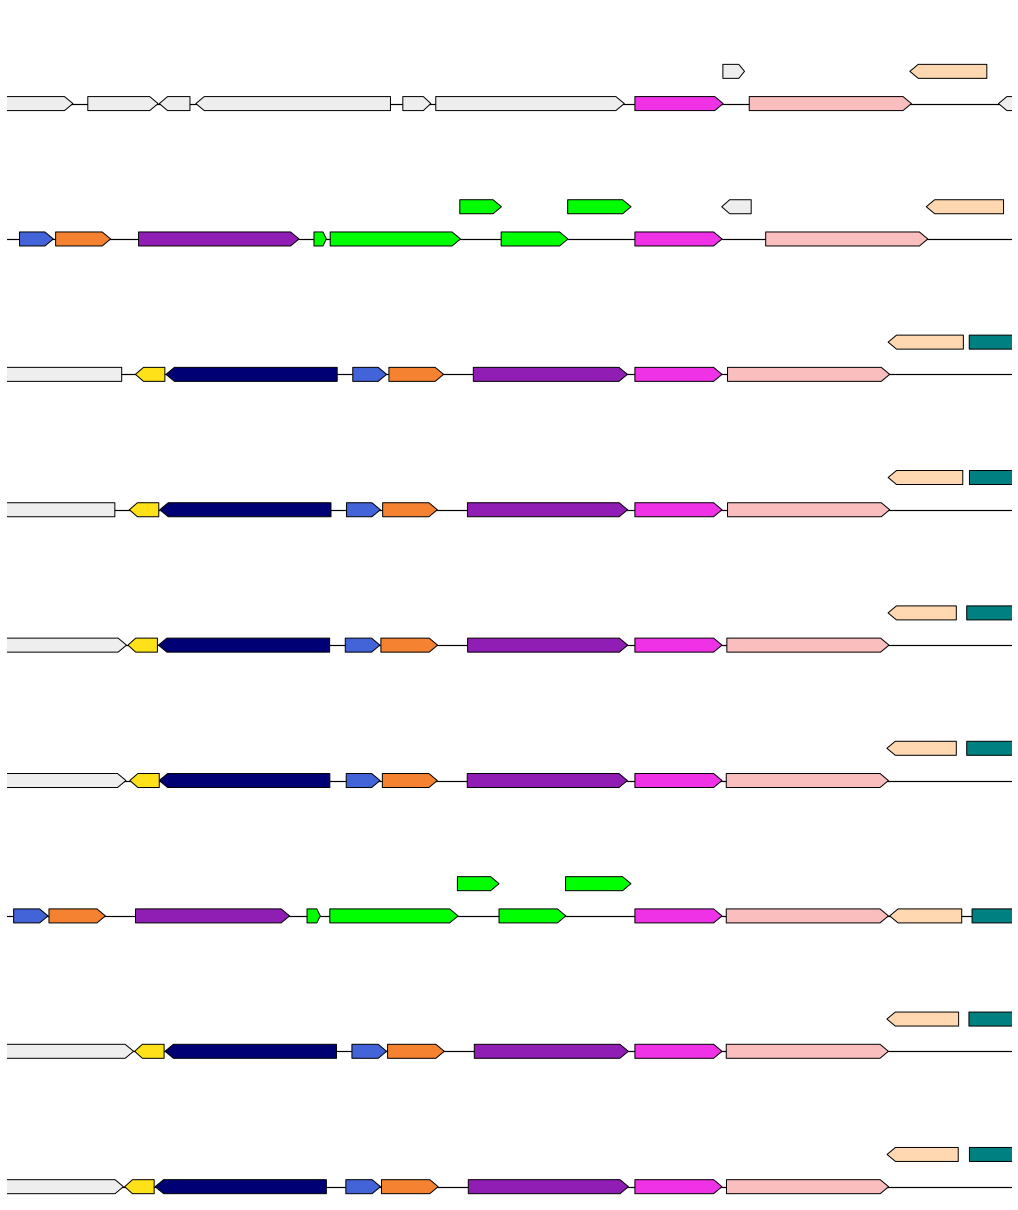

In [571]:
n_rows = len(thermococcus_accessions)
fig, axes = plt.subplots(n_rows, 1, figsize=(18, 2 * len(accessions)))

max_display_length_left = 6_500
max_display_length_right = 3_900
for i, accession in enumerate(thermococcus_accessions):
    ax = axes[i]
    row = thermococcus_species.loc[accession]
    gtdb_species = row['gtdb_species']
    pantoate_protein_id = pantoate_protein_ids[accession]

    gene_context = thermococcus_contexts[accession]

    strand = gene_context.loc[pantoate_protein_id, 'strand']

    if strand == '-':
        # swap
        df = gene_context.reset_index()
        contig_length = df['end'].max()
        old_start = df['start'].copy()
        old_end = df['end'].copy()

        df['start'] = contig_length - old_end + 1
        df['end'] = contig_length - old_start + 1

        df['strand'] = df['strand'].map({'+': '-', '-': '+'})

        # 4. Re-order Proteins by their new start position
        gene_context = df.sort_values(by='start').reset_index(drop=True).set_index('protein_id')
    
    ax = plot_genes(gene_context, ax=ax, no_labels=True, color_map=color_map, default_color=default_color);

    left = gene_context.loc[pantoate_protein_id, 'start'] - max_display_length_left
    right = gene_context.loc[pantoate_protein_id, 'start'] + max_display_length_right
    ax.set_xlim(left, right)
    ax.get_xaxis().set_visible(False)
    #ax.set_title(gtdb_species)

fig.savefig(f'/Users/rs1521/Documents/00_Thesis/figures/raw/Thermococcus_gene_context_raw.pdf', dpi=300, bbox_inches='tight')

In [558]:
accession = 'GCF_000816105.1'
gtdb_species = gtdb_metadata.loc[accession, 'gtdb_species']

folder = subtilosin_A_folder / 'Thermococcus_others' / gtdb_species

gff_file = None
for f in folder.iterdir():
    if f.name.endswith('.gff.gz'):
        gff_file = f
        break

assert gff_file is not None

gff = parse_gff(gff_file)

gene_context = get_context(
    gff, 
    'WP_062370675.1', 
    n_upstream=5_000,
    n_downstream=5_000,
)
gene_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_062370664.1,NZ_CP007140.1,Protein Homology,CDS,422393,422851,.,+,0,ID=cds-WP_062370664.1;Parent=gene-X802_RS02310...,RNA-binding protein
WP_062370665.1,NZ_CP007140.1,Protein Homology,CDS,422848,423492,.,+,0,ID=cds-WP_062370665.1;Parent=gene-X802_RS02315...,Ribonuclease P protein component 3
WP_062370668.1,NZ_CP007140.1,Protein Homology,CDS,423505,424506,.,+,0,ID=cds-WP_062370668.1;Parent=gene-X802_RS02320...,TIGR00341 family protein
WP_062370669.1,NZ_CP007140.1,Protein Homology,CDS,424510,425832,.,-,0,ID=cds-WP_062370669.1;Parent=gene-X802_RS02325...,TrpB-like pyridoxal phosphate-dependent enzyme
WP_062370671.1,NZ_CP007140.1,Protein Homology,CDS,426156,426575,.,-,0,ID=cds-WP_062370671.1;Parent=gene-X802_RS02330...,hypothetical protein
WP_062370673.1,NZ_CP007140.1,Protein Homology,CDS,426757,427212,.,+,0,ID=cds-WP_062370673.1;Parent=gene-X802_RS02335...,hypothetical protein
WP_062370675.1,NZ_CP007140.1,Protein Homology,CDS,427341,429242,.,-,0,ID=cds-WP_062370675.1;Parent=gene-X802_RS02340...,Na+/H+ antiporter NhaC family protein
WP_245608355.1,NZ_CP007140.1,Protein Homology,CDS,429548,430117,.,-,0,ID=cds-WP_245608355.1;Parent=gene-X802_RS02345...,uracil-DNA glycosylase
WP_062370679.1,NZ_CP007140.1,Protein Homology,CDS,430141,430491,.,-,0,ID=cds-WP_062370679.1;Parent=gene-X802_RS02350...,hypothetical protein


In [574]:
T_celer_context

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_088863138.1,NZ_CP014854.1,Protein Homology,CDS,1142436,1142879,.,+,0,ID=cds-WP_088863138.1;Parent=gene-A3L02_RS0635...,Tfx family DNA-binding protein
WP_088863139.1,NZ_CP014854.1,Protein Homology,CDS,1143000,1144457,.,+,0,ID=cds-WP_088863139.1;Parent=gene-A3L02_RS0636...,DUF2139 domain-containing protein
WP_088863140.1,NZ_CP014854.1,Protein Homology,CDS,1144495,1144800,.,-,0,ID=cds-WP_088863140.1;Parent=gene-A3L02_RS0636...,DUF3213 domain-containing protein
WP_237268581.1,NZ_CP014854.1,Protein Homology,CDS,1144811,1147942,.,-,0,ID=cds-WP_237268581.1;Parent=gene-A3L02_RS0637...,radical SAM protein
WP_088863141.1,NZ_CP014854.1,Protein Homology,CDS,1148127,1148483,.,+,0,ID=cds-WP_088863141.1;Parent=gene-A3L02_RS0637...,hypothetical protein
WP_088863142.1,NZ_CP014854.1,Protein Homology,CDS,1148493,1149077,.,+,0,ID=cds-WP_088863142.1;Parent=gene-A3L02_RS0638...,type-4 uracil-DNA glycosylase
WP_088863143.1,NZ_CP014854.1,Protein Homology,CDS,1149389,1150984,.,+,0,ID=cds-WP_088863143.1;Parent=gene-A3L02_RS0638...,Na+/H+ antiporter NhaC family protein
WP_088863144.1,NZ_CP014854.1,Protein Homology,CDS,1151165,1151302,.,+,0,ID=cds-WP_088863144.1;Parent=gene-A3L02_RS0639...,subtilosin A family bacteriocin
WP_088863145.1,NZ_CP014854.1,Protein Homology,CDS,1151401,1152729,.,+,0,ID=cds-WP_088863145.1;Parent=gene-A3L02_RS0639...,radical SAM protein


In [575]:
thermococcus_contexts['GCF_000009965.1']

,contig_id,source,type,start,end,na1,strand,na2,metadata,description
protein_id,,,,,,,,,,
WP_011251080.1,NC_006624.1,Protein Homology,CDS,1911383,1911910,.,+,0,ID=cds-WP_011251080.1;Parent=gene-TK_RS10690;D...,cob(I)yrinic acid a%2Cc-diamide adenosyltransf...
WP_011251081.1,NC_006624.1,Protein Homology,CDS,1912015,1912266,.,+,0,ID=cds-WP_011251081.1;Parent=gene-TK_RS10695;D...,UPF0147 family protein
WP_011251082.1,NC_006624.1,Protein Homology,CDS,1912285,1912839,.,-,0,ID=cds-WP_011251082.1;Parent=gene-TK_RS10700;D...,aldolase
WP_011251083.1,NC_006624.1,Protein Homology,CDS,1912836,1913414,.,-,0,ID=cds-WP_011251083.1;Parent=gene-TK_RS10705;D...,membrane protein
WP_011251084.1,NC_006624.1,Protein Homology,CDS,1913751,1914176,.,-,0,ID=cds-WP_011251084.1;Parent=gene-TK_RS10715;D...,Lrp/AsnC family transcriptional regulator
WP_048053885.1,NC_006624.1,Protein Homology,CDS,1914246,1915496,.,-,0,ID=cds-WP_048053885.1;Parent=gene-TK_RS10720;D...,23S rRNA (uracil(1939)-C(5))-methyltransferase...
WP_011251086.1,NC_006624.1,Protein Homology,CDS,1915616,1915843,.,+,0,ID=cds-WP_011251086.1;Parent=gene-TK_RS10725;D...,hypothetical protein
WP_011251087.1,NC_006624.1,Protein Homology,CDS,1915885,1916715,.,+,0,ID=cds-WP_011251087.1;Parent=gene-TK_RS10730;D...,MinD/ParA family protein
WP_011251088.1,NC_006624.1,Protein Homology,CDS,1916674,1917231,.,-,0,ID=cds-WP_011251088.1;Parent=gene-TK_RS10735;D...,orotate phosphoribosyltransferase
